<a href="https://colab.research.google.com/github/aditya-singh004/Customer-Churn-Predicton-/blob/main/churn_prediction_using_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

df.shape

Saving churn (2).csv to churn (2).csv


(10000, 14)

# 1- EDA

In [4]:
# The first 5 observation
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# The size of the data set
df.shape

(10000, 14)

In [6]:
# Feature information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
# Descriptive statistics of the data set
df.describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
5%,500.95000,1.557882e+07,489.000000,25.000000,1.000000,0.000000,1.000000,0.00000,0.000000,9851.818500,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
90%,9000.10000,1.579083e+07,778.000000,53.000000,9.000000,149244.792000,2.000000,1.00000,1.000000,179674.704000,1.000000
95%,9500.05000,1.580303e+07,812.000000,60.000000,9.000000,162711.669000,2.000000,1.00000,1.000000,190155.375500,1.000000


In [8]:
categorical_variables = [
    col for col in df.columns
    if (df[col].dtype == "object" or df[col].nunique() <= 11) and col != "Exited"
]

categorical_variables

['Surname',
 'Geography',
 'Gender',
 'Tenure',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember']

In [9]:
numeric_variables = [
    col for col in df.columns
    if (df[col].dtype != "object" and df[col].nunique() > 11) and col != "CustomerId"
]

numeric_variables

['RowNumber', 'CreditScore', 'Age', 'Balance', 'EstimatedSalary']

## Exited (Dependent Variable)

In [10]:
# Frequency of classes of dependent variable
df["Exited"].value_counts(normalize=True)

,proportion
Exited,
0,0.7963
1,0.2037


In [11]:
# Customers leaving the bank
churn = df[df["Exited"] == 1].copy()

In [12]:
# Customers who did not leave the bank
not_churn = df[df["Exited"] == 0].copy()

# Categorical Variables

## Tenure

In [13]:
# Frequency of not_churn group according to Tenure
not_churn["Tenure"].value_counts().sort_values()

,count
Tenure,
0,318
10,389
9,771
6,771
4,786
3,796
5,803
1,803
8,828


In [14]:
# Frequency of churn group according to Tenure
churn["Tenure"].value_counts().sort_values()

,count
Tenure,
0,95
10,101
7,177
6,196
8,197
2,201
4,203
5,209
3,213


## NumOfProducts

In [15]:
# Frequency of not_churn group according to NumOfProducts
not_churn["NumOfProducts"].value_counts().sort_values()

,count
NumOfProducts,
3,46
1,3675
2,4242


In [16]:
# Frequency of churn group according to NumOfProducts
churn["NumOfProducts"].value_counts().sort_values()

,count
NumOfProducts,
4,60
3,220
2,348
1,1409


## HasCrCard

In [17]:
# examining the HasCrCard of the not_churn group
not_churn["HasCrCard"].value_counts()

,count
HasCrCard,
1,5631
0,2332


In [18]:
# examining the HasCrCard of the churn group
churn["HasCrCard"].value_counts()

,count
HasCrCard,
1,1424
0,613


## IsActiveMember

In [19]:
# examining the IsActiveMember of the not_churn group
not_churn["IsActiveMember"].value_counts()

,count
IsActiveMember,
1,4416
0,3547


In [20]:
# examining the IsActiveMember of the churn group
churn["IsActiveMember"].value_counts()

,count
IsActiveMember,
0,1302
1,735


## Geography

In [21]:
# Frequency of not_churn group according to Geography
not_churn.Geography.value_counts().sort_values()

,count
Geography,
Germany,1695
Spain,2064
France,4204


In [22]:
# Frequency of churn group according to Geography
churn.Geography.value_counts().sort_values()

,count
Geography,
Spain,413
France,810
Germany,814


## Gender

In [23]:
# Frequency of not_churn group according to Gender
not_churn.Gender.value_counts()

,count
Gender,
Male,4559
Female,3404


In [24]:
# Frequency of churn group according to Gender
churn.Gender.value_counts()

,count
Gender,
Female,1139
Male,898


# Numerical Variables

## CreditScore

In [25]:
# Let's examine the credit score of the not_churn group
not_churn["CreditScore"].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

,CreditScore
count,7963.000000
mean,651.853196
std,95.653837
min,405.000000
5%,492.000000
25%,585.000000
50%,653.000000
75%,718.000000
90%,778.000000
95%,812.000000


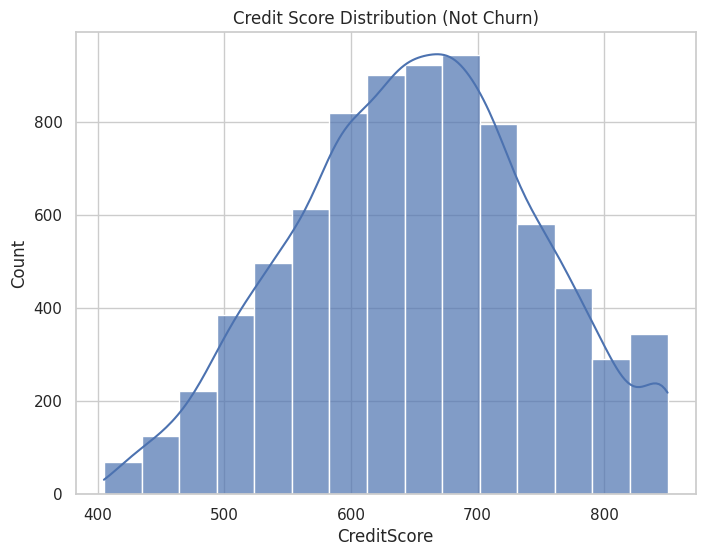

In [26]:
# distribution of the Credit Score for not_churn
plt.figure(figsize=(8, 6))
sns.histplot(not_churn["CreditScore"], bins=15, kde=True, alpha=0.7)
plt.xlabel("CreditScore")
plt.title("Credit Score Distribution (Not Churn)")
plt.show()

In [27]:
# Let's examine the credit score of the churn group
churn["CreditScore"].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

,CreditScore
count,2037.000000
mean,645.351497
std,100.321503
min,350.000000
5%,479.000000
25%,578.000000
50%,646.000000
75%,716.000000
90%,776.400000
95%,812.200000


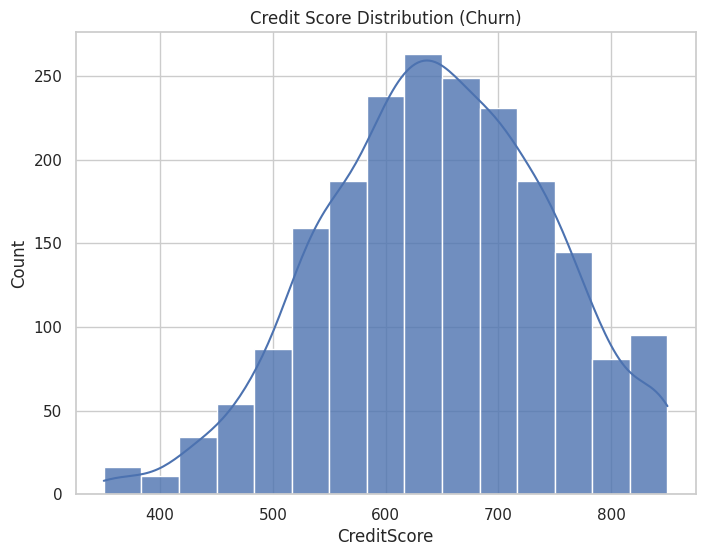

In [28]:
# distribution of the Credit Score for churn
plt.figure(figsize=(8, 6))
sns.histplot(churn["CreditScore"], bins=15, kde=True, alpha=0.8)
plt.xlabel("CreditScore")
plt.title("Credit Score Distribution (Churn)")
plt.show()

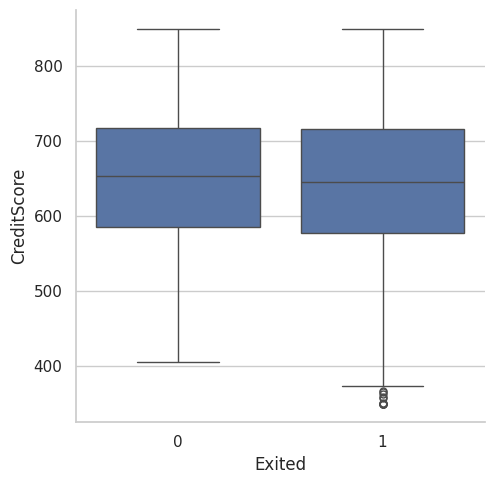

In [29]:
sns.catplot(x="Exited", y="CreditScore", data=df, kind="box")

## Age

In [30]:
# examining the age of the not_churn group
not_churn["Age"].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

,Age
count,7963.000000
mean,37.408389
std,10.125363
min,18.000000
5%,24.000000
25%,31.000000
50%,36.000000
75%,41.000000
90%,49.000000
95%,59.000000


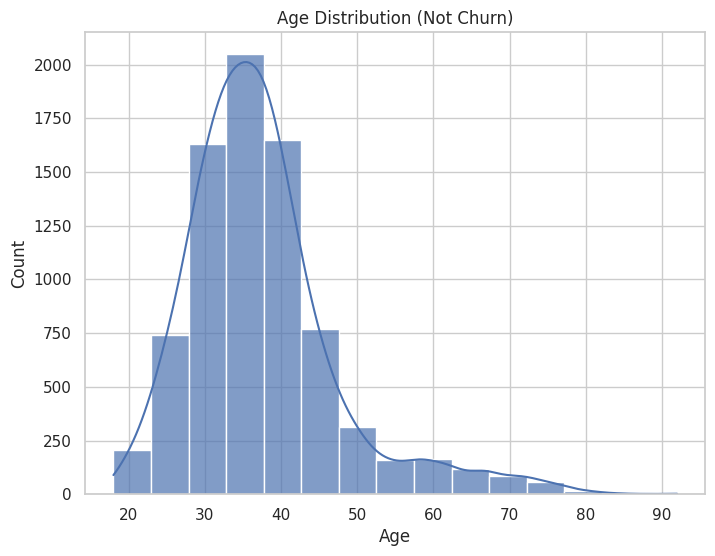

In [31]:
# distribution of the Age for not_churn
plt.figure(figsize=(8, 6))
sns.histplot(not_churn["Age"], bins=15, kde=True, alpha=0.7)
plt.xlabel("Age")
plt.title("Age Distribution (Not Churn)")
plt.show()

In [32]:
# examine the age of the churn group
churn["Age"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

,Age
count,2037.000000
mean,44.837997
std,9.761562
min,18.000000
5%,29.000000
25%,38.000000
50%,45.000000
75%,51.000000
90%,58.000000
95%,61.000000


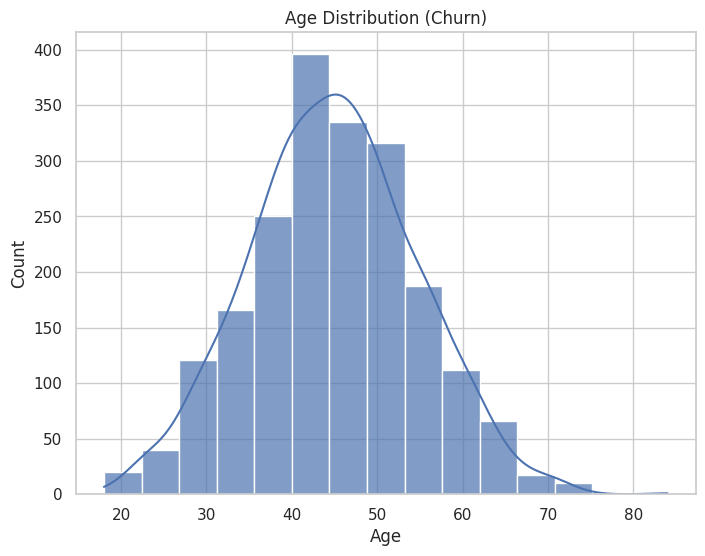

In [33]:
# distribution of the Age for not_churn
plt.figure(figsize=(8, 6))
sns.histplot(churn["Age"], bins=15, kde=True, alpha=0.7)
plt.xlabel("Age")
plt.title("Age Distribution (Churn)")
plt.show()

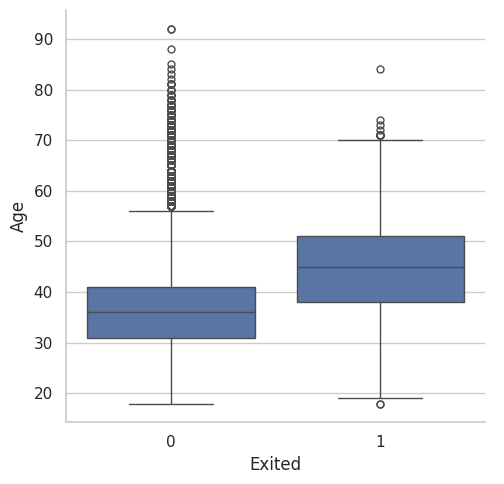

In [34]:
sns.catplot(x="Exited", y="Age", data=df, kind="box")

## Balance

In [35]:
# examining the Balance of the not_churn group
not_churn["Balance"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

,Balance
count,7963.000000
mean,72745.296779
std,62848.040701
min,0.000000
5%,0.000000
25%,0.000000
50%,92072.680000
75%,126410.280000
90%,148730.298000
95%,161592.595000


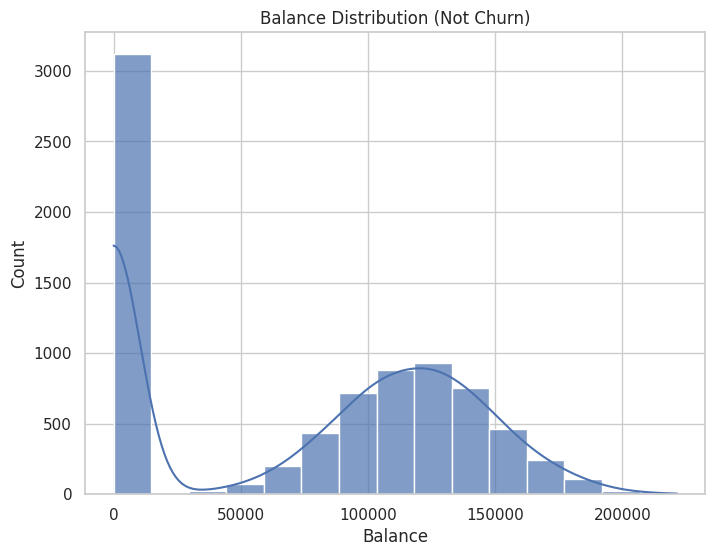

In [36]:
# distribution of the Balance for not_churn
plt.figure(figsize=(8, 6))
sns.histplot(not_churn["Balance"], bins=15, kde=True, alpha=0.7)
plt.xlabel("Balance")
plt.title("Balance Distribution (Not Churn)")
plt.show()

In [37]:
# examining the Balance of the churn group
churn["Balance"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

,Balance
count,2037.000000
mean,91108.539337
std,58360.794816
min,0.000000
5%,0.000000
25%,38340.020000
50%,109349.290000
75%,131433.330000
90%,152080.618000
95%,167698.240000


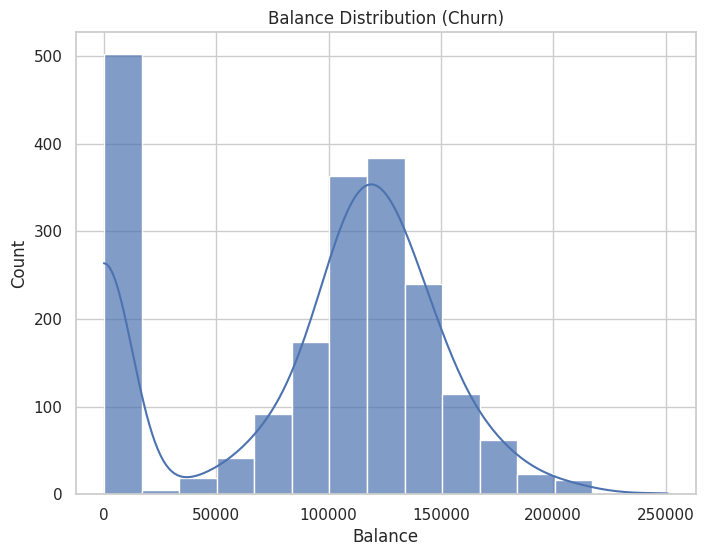

In [38]:
# distribution of the Balance for churn
plt.figure(figsize=(8, 6))
sns.histplot(churn["Balance"], bins=15, kde=True, alpha=0.7)
plt.xlabel("Balance")
plt.title("Balance Distribution (Churn)")
plt.show()

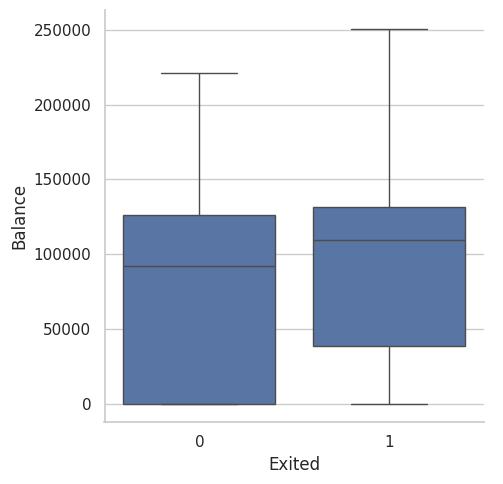

In [39]:
sns.catplot(x="Exited", y="Balance", data=df, kind="box")

## EstimatedSalary

In [40]:
# examining the EstimatedSalary of the not_churn group
not_churn["EstimatedSalary"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

,EstimatedSalary
count,7963.000000
mean,99738.391772
std,57405.586966
min,90.070000
5%,9773.542000
25%,50783.490000
50%,99645.040000
75%,148609.955000
90%,179453.212000
95%,190107.557000


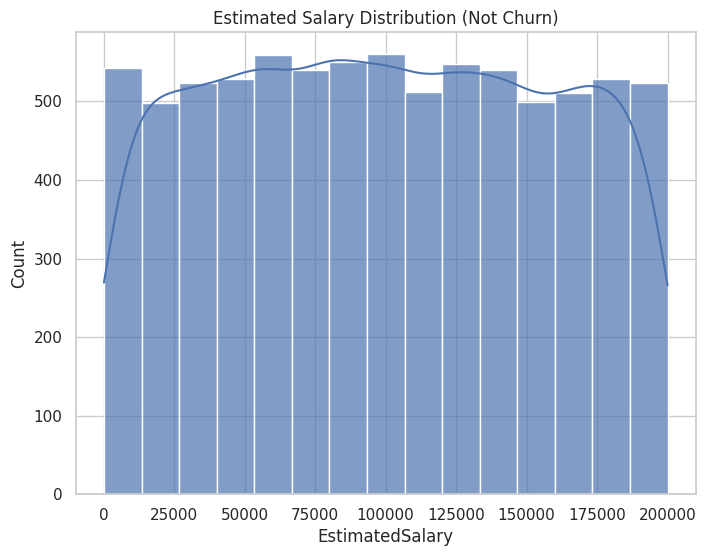

In [41]:
# distribution of the Balance for churn
plt.figure(figsize=(8, 6))
sns.histplot(not_churn["EstimatedSalary"], bins=15, kde=True, alpha=0.7)
plt.xlabel("EstimatedSalary")
plt.title("Estimated Salary Distribution (Not Churn)")
plt.show()

In [42]:
# examining the EstimatedSalary of the churn group
churn["EstimatedSalary"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

,EstimatedSalary
count,2037.000000
mean,101465.677531
std,57912.418071
min,11.580000
5%,10030.760000
25%,51907.720000
50%,102460.840000
75%,152422.910000
90%,180169.390000
95%,190328.982000


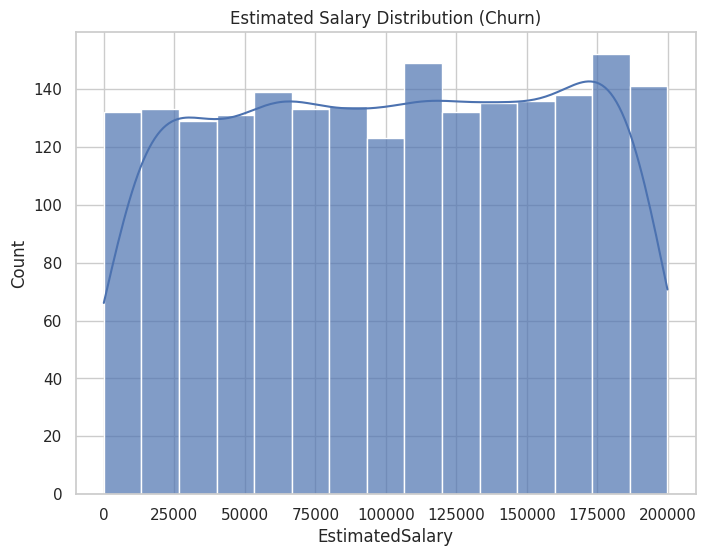

In [43]:
# distribution of the EstimatedSalary for churn
plt.figure(figsize=(8, 6))
sns.histplot(churn["EstimatedSalary"], bins=15, kde=True, alpha=0.7)
plt.xlabel("EstimatedSalary")
plt.title("Estimated Salary Distribution (Churn)")
plt.show()

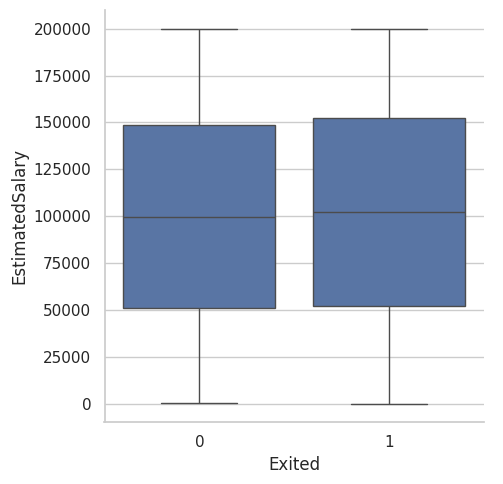

In [44]:
sns.catplot(x="Exited", y="EstimatedSalary", data=df, kind="box")

# Correlation Matrix

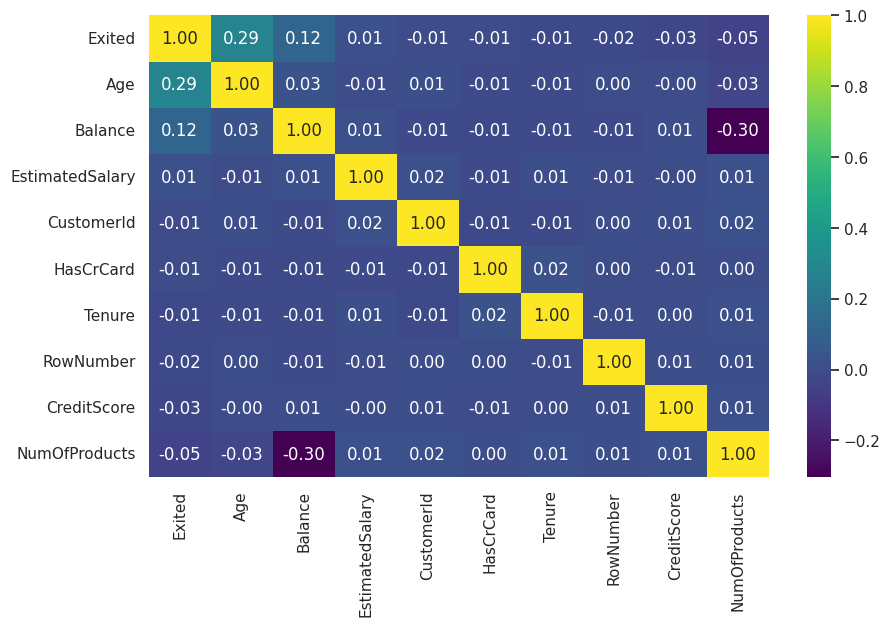

In [45]:
# Exited correlation matrix
k = 10
corr = df.corr(numeric_only=True)
cols = corr["Exited"].nlargest(k).index
cm = df[cols].corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, cmap="viridis", fmt=".2f")
plt.show()


# 2- Data Preprocessing

## Missing Value

In [46]:
# # Missing Observation Analysis
df.isnull().sum().sort_values(ascending=False)

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


## Outliers

In [47]:
# To determine the threshold value for outliers
def outlier_thresholds(dataframe, variable, low_quantile=0.05, up_quantile=0.95):
    q_low = dataframe[variable].quantile(low_quantile)
    q_high = dataframe[variable].quantile(up_quantile)
    iqr = q_high - q_low
    lower = q_low - 1.5 * iqr
    upper = q_high + 1.5 * iqr
    return lower, upper

In [48]:
# Are there any outliers in the variables
def has_outliers(dataframe, numeric_columns, plot=False):
    for col in numeric_columns:
        low_limit, up_limit = outlier_thresholds(dataframe, col)
        mask = (dataframe[col] < low_limit) | (dataframe[col] > up_limit)
        if mask.any():
            number_of_outliers = mask.sum()
            print(f"{col} : {number_of_outliers} outliers")
            if plot:
                sns.boxplot(x=dataframe[col])
                plt.title(col)
                plt.show()

In [49]:
# There is no outlier
for var in numeric_variables:
    print(var, "has " , has_outliers(df, [var]),  "Outliers")

RowNumber has  None Outliers
CreditScore has  None Outliers
Age has  None Outliers
Balance has  None Outliers
EstimatedSalary has  None Outliers


## Feature Engineering

In [50]:
# we standardize tenure with age
df["NewTenure"] = df["Tenure"]/df["Age"]
df["NewCreditsScore"] = pd.qcut(df['CreditScore'], 6, labels = [1, 2, 3, 4, 5, 6])
df["NewAgeScore"] = pd.qcut(df['Age'], 8, labels = [1, 2, 3, 4, 5, 6, 7, 8])
df["NewBalanceScore"] = pd.qcut(df['Balance'].rank(method="first"), 5, labels = [1, 2, 3, 4, 5])
df["NewEstSalaryScore"] = pd.qcut(df['EstimatedSalary'], 10, labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

In [51]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,NewTenure,NewCreditsScore,NewAgeScore,NewBalanceScore,NewEstSalaryScore
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.047619,3,6,1,6
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.024390,2,6,3,6
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0.190476,1,6,5,6
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.025641,5,5,1,5
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0.046512,6,6,4,4


## One Hot Encoding

In [52]:
# Modern One-Hot Encoding
encoding_cols = ["Gender", "Geography"]
# Check if the columns still exist before attempting to encode them
cols_to_encode_now = [col for col in encoding_cols if col in df.columns]

if cols_to_encode_now:
    df = pd.get_dummies(df, columns=cols_to_encode_now, drop_first=True, dtype="int8")
    print(f"Successfully applied one-hot encoding for: {cols_to_encode_now}")
else:
    print(f"Columns {encoding_cols} were already one-hot encoded or do not exist in the DataFrame.")

Successfully applied one-hot encoding for: ['Gender', 'Geography']


In [53]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,NewTenure,NewCreditsScore,NewAgeScore,NewBalanceScore,NewEstSalaryScore,Gender_Male,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,0.047619,3,6,1,6,0,0,0
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,0.024390,2,6,3,6,0,0,1
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,0.190476,1,6,5,6,0,0,0
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,0.025641,5,5,1,5,0,0,0
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,0.046512,6,6,4,4,0,0,1


# Scalling

In [54]:
# Removing variables that will not affect the dependent variable
df = df.drop(columns=["CustomerId", "Surname"], errors="ignore")

In [55]:
from sklearn.preprocessing import RobustScaler

def apply_robust_scaling(dataframe, columns):
    scaler = RobustScaler()
    dataframe = dataframe.copy()
    dataframe.loc[:, columns] = scaler.fit_transform(dataframe[columns])
    return dataframe

In [56]:
# Modern Scaling with RobustScaler
new_cols_ohe = [col for col in df.columns if col.startswith(("Gender_", "Geography_"))]
like_num = [col for col in df.columns if df[col].dtype != "object" and df[col].nunique() <= 11]

cols_need_scale = [
    col for col in df.columns
    if col not in new_cols_ohe
    and col != "Exited"
    and col not in like_num
]

scaler = RobustScaler()
df.loc[:, cols_need_scale] = scaler.fit_transform(df[cols_need_scale])

/tmp/ipykernel_6921/3255202730.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.         -0.99979998 -0.99959996 ...  0.99959996  0.99979998
  1.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, cols_need_scale] = scaler.fit_transform(df[cols_need_scale])
/tmp/ipykernel_6921/3255202730.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.24626866 -0.32835821 -1.11940299 ...  0.42537313  0.89552239
  1.04477612]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, cols_need_scale] = scaler.fit_transform(df[cols_need_scale])
/tmp/ipykernel_6921/3255202730.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.41666667  0.33333333  0.41666667 ... -0.08333333

In [57]:
df.head()

,RowNumber,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,NewTenure,NewCreditsScore,NewAgeScore,NewBalanceScore,NewEstSalaryScore,Gender_Male,Geography_Germany,Geography_Spain
0,-1.0000,-0.246269,0.416667,2,-0.761480,1,1,1,0.011739,1,-0.600907,3,6,1,6,0,0,0
1,-0.9998,-0.328358,0.333333,1,-0.104906,1,0,1,0.125512,0,-0.772358,2,6,3,6,0,0,1
2,-0.9996,-1.119403,0.416667,8,0.489346,3,1,0,0.139630,1,0.453515,1,6,5,6,0,0,0
3,-0.9994,0.350746,0.166667,1,-0.761480,2,0,0,-0.064717,0,-0.763126,5,5,1,5,0,0,0
4,-0.9992,1.477612,0.500000,2,0.221806,1,1,1,-0.214561,0,-0.609081,6,6,4,4,0,0,1


# 3- Modeling

In [58]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

models = [
    ("LR", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ("KNN", KNeighborsClassifier()),
    ("CART", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ("RF", RandomForestClassifier(random_state=RANDOM_STATE)),
    ("SVC", SVC(gamma="auto", probability=True, random_state=RANDOM_STATE)),
    ("GB", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ("LightGBM", LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1))
]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

for name, model in models:
    cv_results = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"{name}: Mean ROC-AUC: {cv_results.mean():.4f} (Std: {cv_results.std():.4f})")

LR: Mean ROC-AUC: 0.7860 (Std: 0.0238)
KNN: Mean ROC-AUC: 0.7186 (Std: 0.0214)
CART: Mean ROC-AUC: 0.6804 (Std: 0.0225)
RF: Mean ROC-AUC: 0.8498 (Std: 0.0201)
SVC: Mean ROC-AUC: 0.7936 (Std: 0.0223)
GB: Mean ROC-AUC: 0.8656 (Std: 0.0172)
LightGBM: Mean ROC-AUC: 0.8586 (Std: 0.0188)


In [59]:
# GB Confusion Matrix
model_GB = GradientBoostingClassifier(random_state=RANDOM_STATE)
model_GB.fit(X_train, y_train)
y_pred = model_GB.predict(X_test)
conf_mat = confusion_matrix(y_test, y_pred)
conf_mat

array([[1541,   52],
       [ 206,  201]])

In [60]:
print("True Positive : ", conf_mat[1, 1])
print("True Negative : ", conf_mat[0, 0])
print("False Positive: ", conf_mat[0, 1])
print("False Negative: ", conf_mat[1, 0])


True Positive :  201
True Negative :  1541
False Positive:  52
False Negative:  206


In [61]:
# Classification Report for XGB Model
y_pred = model_GB.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



In [62]:
# Auc Roc Curve
def generate_auc_roc_curve(clf, X_test, y_test):
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    RocCurveDisplay.from_predictions(y_test, y_pred_proba, name=f"AUC = {auc:.4f}")
    plt.show()

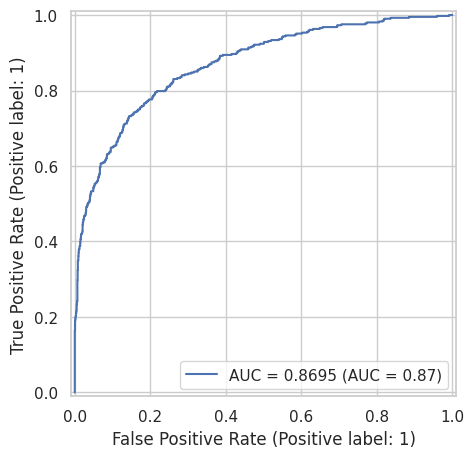

In [63]:
generate_auc_roc_curve(model_GB, X_test, y_test)

# 4- Model Tuning

In [64]:
# LightGBM Hyperparameter Tuning using GridSearchCV
lgb_model = LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1)

lgbm_params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 5, 8],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lgbm_grid = GridSearchCV(
    estimator=lgb_model,
    param_grid=lgbm_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)

lgbm_tuned = lgbm_grid.fit(X, y)

print(f"Best parameters for LightGBM: {lgbm_tuned.best_params_}")

Best parameters for LightGBM: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}


In [65]:
# Gradient Boosting Hyperparameter Tuning using GridSearchCV
gbm_model = GradientBoostingClassifier(random_state=RANDOM_STATE)

gbm_params = {
    "learning_rate": [0.01, 0.1],
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gbm_grid = GridSearchCV(
    estimator=gbm_model,
    param_grid=gbm_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)

gbm_tuned = gbm_grid.fit(X_train, y_train)

print(f"Best parameters for GBM: {gbm_tuned.best_params_}")

Best parameters for GBM: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [67]:
# Evaluate optimized models using cross-validation
models = [
    ("LightGBM", lgbm_tuned.best_estimator_),
    ("GB", gbm_tuned.best_estimator_)
]

results = []
names = []

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

for name, model in models:
    cv_results = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean():.6f} ({cv_results.std():.6f})")

LightGBM: 0.868449 (0.018066)
GB: 0.865587 (0.017217)


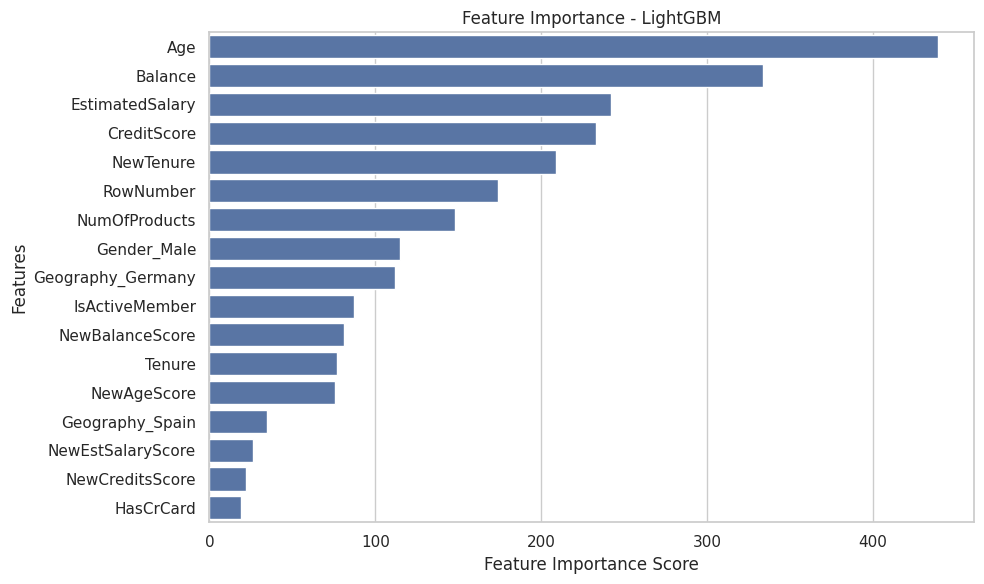

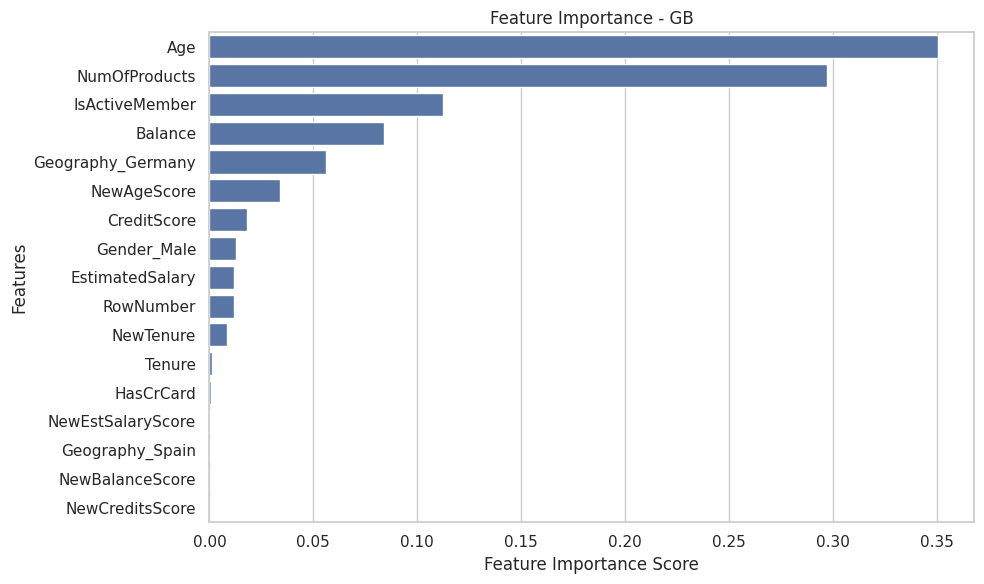

In [68]:
# Visualize feature importances for optimized models
for name, model in models:
    model.fit(X_train, y_train)

    if hasattr(model, "feature_importances_"):
        feature_imp = pd.Series(
            model.feature_importances_, index=X.columns
        ).sort_values(ascending=False)
    else:
        continue

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_imp.values, y=feature_imp.index)
    plt.xlabel("Feature Importance Score")
    plt.ylabel("Features")
    plt.title(f"Feature Importance - {name}")
    plt.tight_layout()
    plt.show()

In [69]:
# Final LightGBM model
final_lgbm = lgbm_tuned.best_estimator_

final_lgbm.fit(X_train, y_train)

y_pred = final_lgbm.predict(X_test)
y_prob = final_lgbm.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000

ROC-AUC: 0.8691048521556997
